# 第9章: 区間推定

## 学習目標
- 信頼区間の概念を理解する
- 正規母集団の平均の信頼区間を構成できる
- 分散の信頼区間を構成できる
- 母比率の信頼区間を構成できる
- ピボット量の方法を理解する

## 📋 学習メタ情報

### 推定学習時間
**90〜120分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

区間推定は、推定の不確実性を定量化する手法です。信頼区間により、推定値の信頼性を評価し、意思決定の根拠とします。

### 実世界での応用

**A/Bテスト**: コンバージョン率の差の信頼区間を計算し、有意性を判断

**医薬品の効果**: 治療効果の95%信頼区間を計算し、承認判断の根拠とする

**経済指標**: GDPや失業率の信頼区間を公表し、政策判断の材料とする

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 9.1 信頼区間の基本概念

### 定義
$100(1-\alpha)\%$ 信頼区間とは、パラメータ $\theta$ に対して:
$$P(L \leq \theta \leq U) = 1 - \alpha$$

### 解釈
- 真のパラメータは固定値
- 信頼区間は確率変数
- 「多数回の標本抽出で、$100(1-\alpha)\%$の区間が真値を含む」

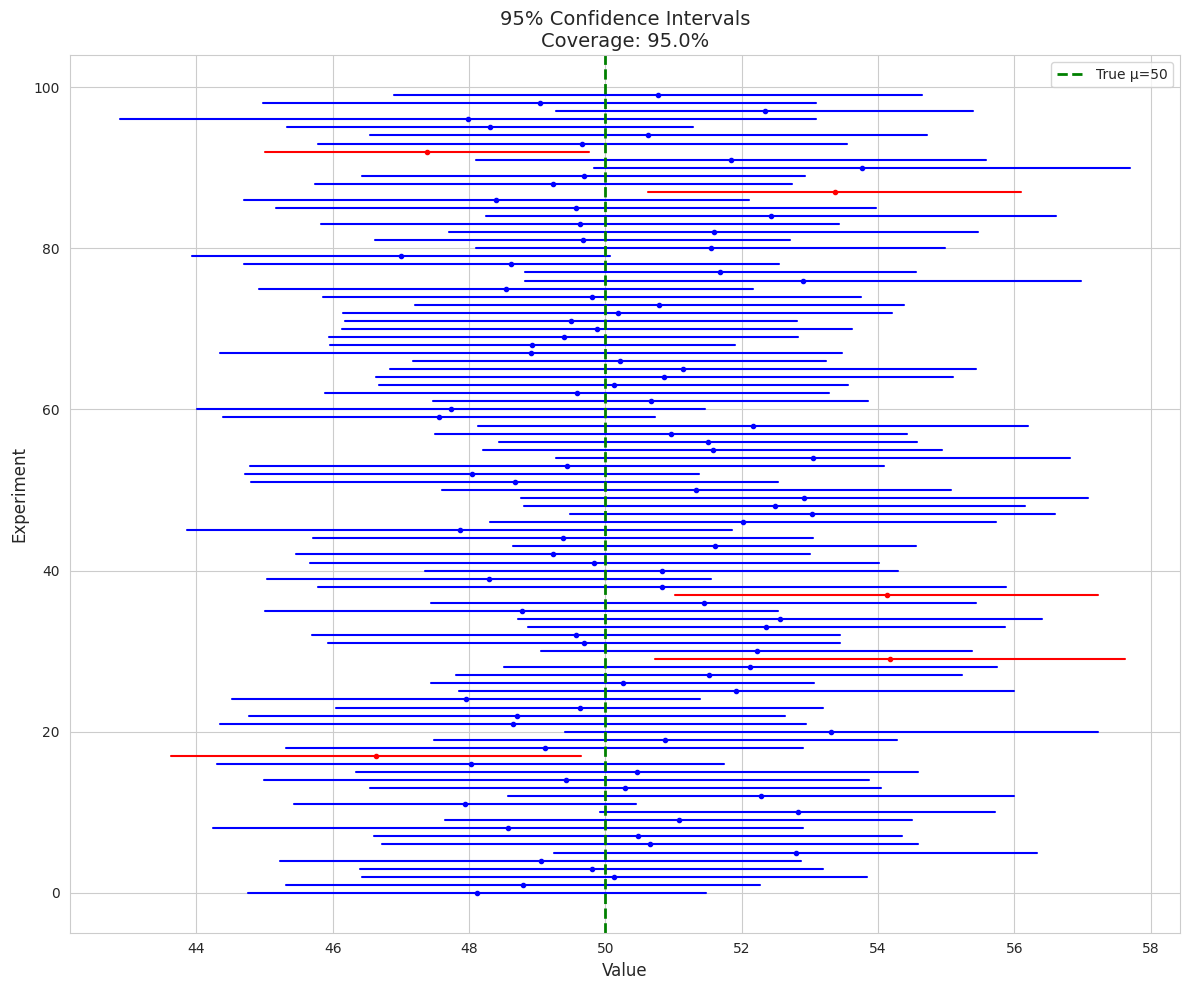

Number of intervals containing true μ: 95/100
Empirical coverage: 95.0%


In [2]:
# 信頼区間の概念の可視化
n_experiments = 100
n = 30
true_mu = 50
true_sigma = 10
alpha = 0.05

# Generate confidence intervals
intervals = []
contains_true = []

for _ in range(n_experiments):
    sample = np.random.normal(true_mu, true_sigma, n)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    
    # t-based confidence interval
    t_crit = stats.t.ppf(1 - alpha/2, n-1)
    margin = t_crit * sample_std / np.sqrt(n)
    lower = sample_mean - margin
    upper = sample_mean + margin
    
    intervals.append((lower, sample_mean, upper))
    contains_true.append(lower <= true_mu <= upper)

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))

for i, (lower, mean, upper) in enumerate(intervals):
    color = 'blue' if contains_true[i] else 'red'
    ax.plot([lower, upper], [i, i], color=color, linewidth=1.5)
    ax.plot(mean, i, 'o', color=color, markersize=3)

ax.axvline(true_mu, color='green', linestyle='--', linewidth=2, label=f'True μ={true_mu}')

coverage = np.mean(contains_true) * 100
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Experiment', fontsize=12)
ax.set_title(f'{int((1-alpha)*100)}% Confidence Intervals\nCoverage: {coverage:.1f}%', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Number of intervals containing true μ: {sum(contains_true)}/{n_experiments}")
print(f"Empirical coverage: {coverage:.1f}%")

## 9.2 正規母集団の平均の信頼区間（分散既知）

### ピボット量
$$Z = \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \sim N(0, 1)$$

### 信頼区間
$$\bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \leq \mu \leq \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}}$$

ここで $z_{\alpha/2}$ は標準正規分布の上側 $\alpha/2$ 点。

Sample mean: 102.10
Known σ: 15
Sample size: 25

Confidence Intervals (σ known):
90% CI: [97.17, 107.04], width = 9.87
95% CI: [96.22, 107.98], width = 11.76
99% CI: [94.37, 109.83], width = 15.45


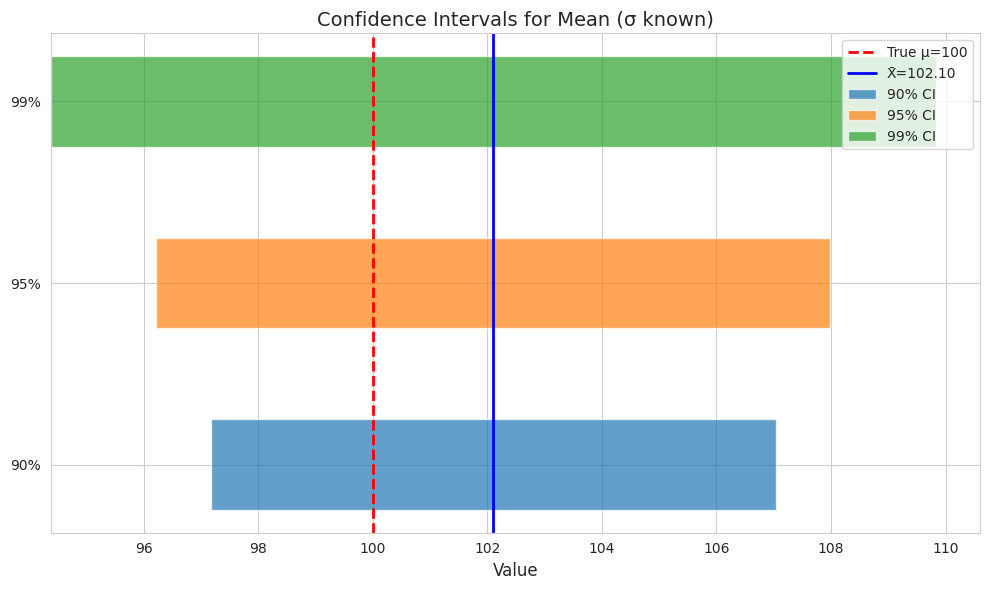

In [3]:
# 分散既知の場合の信頼区間
np.random.seed(123)
n = 25
true_mu = 100
true_sigma = 15  # Known

sample = np.random.normal(true_mu, true_sigma, n)
sample_mean = np.mean(sample)

# Different confidence levels
confidence_levels = [0.90, 0.95, 0.99]

print(f"Sample mean: {sample_mean:.2f}")
print(f"Known σ: {true_sigma}")
print(f"Sample size: {n}")
print("\nConfidence Intervals (σ known):")
print("="*50)

fig, ax = plt.subplots(figsize=(10, 6))

for i, conf in enumerate(confidence_levels):
    alpha = 1 - conf
    z_crit = stats.norm.ppf(1 - alpha/2)
    margin = z_crit * true_sigma / np.sqrt(n)
    lower = sample_mean - margin
    upper = sample_mean + margin
    
    print(f"{int(conf*100)}% CI: [{lower:.2f}, {upper:.2f}], width = {upper-lower:.2f}")
    
    ax.barh(i, upper - lower, left=lower, height=0.5, alpha=0.7, 
            label=f'{int(conf*100)}% CI')

ax.axvline(true_mu, color='red', linestyle='--', linewidth=2, label=f'True μ={true_mu}')
ax.axvline(sample_mean, color='blue', linestyle='-', linewidth=2, label=f'X̄={sample_mean:.2f}')
ax.set_yticks(range(len(confidence_levels)))
ax.set_yticklabels([f'{int(c*100)}%' for c in confidence_levels])
ax.set_xlabel('Value', fontsize=12)
ax.set_title('Confidence Intervals for Mean (σ known)', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 9.3 正規母集団の平均の信頼区間（分散未知）

### ピボット量
$$T = \frac{\bar{X} - \mu}{S/\sqrt{n}} \sim t(n-1)$$

### 信頼区間
$$\bar{X} - t_{\alpha/2}(n-1) \frac{S}{\sqrt{n}} \leq \mu \leq \bar{X} + t_{\alpha/2}(n-1) \frac{S}{\sqrt{n}}$$

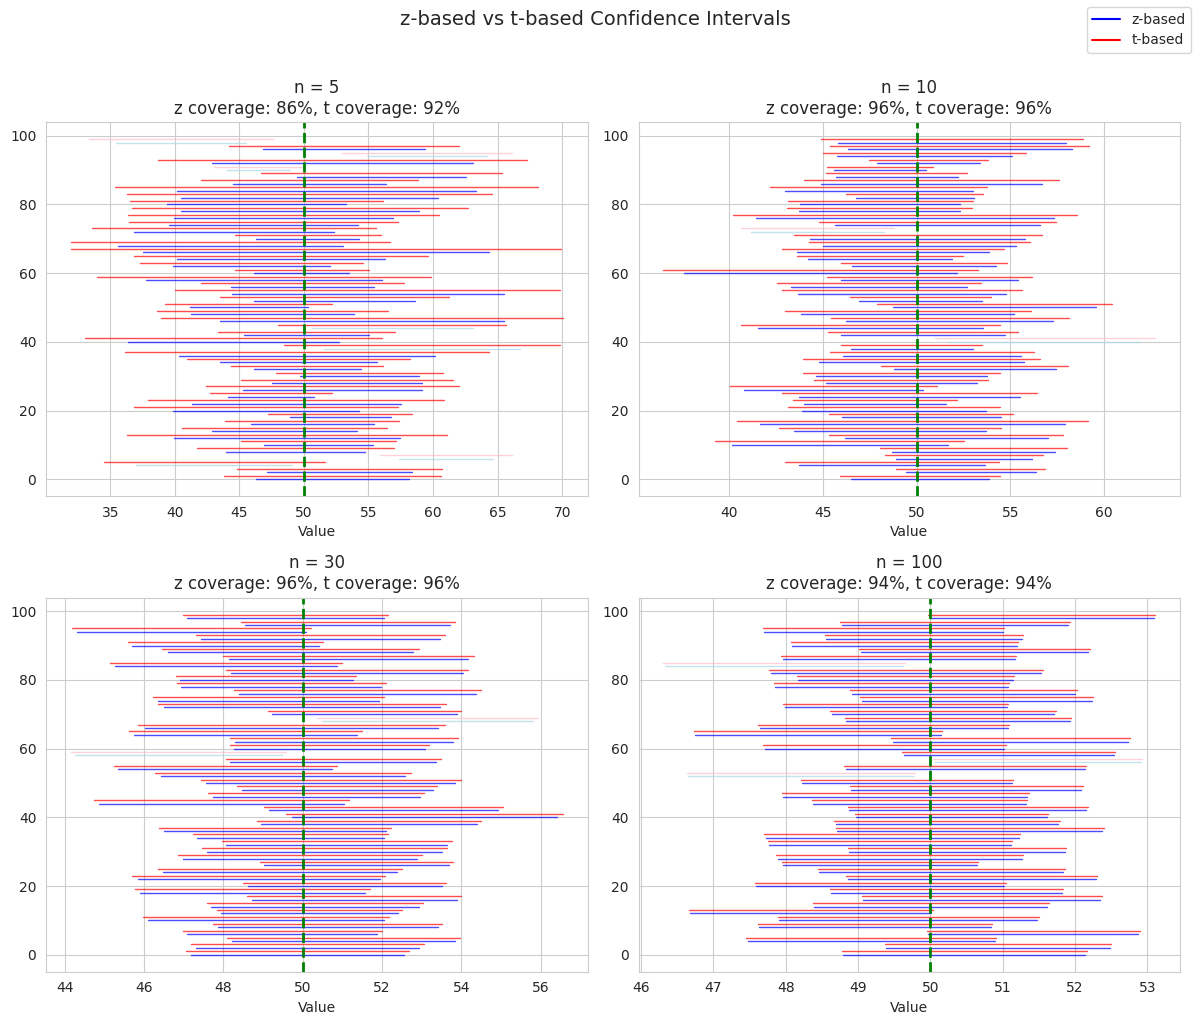

In [4]:
# 分散未知の場合の信頼区間
np.random.seed(456)
sample_sizes = [5, 10, 30, 100]
true_mu = 50
true_sigma = 8
alpha = 0.05

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, n in enumerate(sample_sizes):
    row, col = idx // 2, idx % 2
    
    # Generate samples and CIs
    n_experiments = 50
    intervals_z = []  # Using z (incorrect when σ unknown)
    intervals_t = []  # Using t (correct)
    
    for _ in range(n_experiments):
        sample = np.random.normal(true_mu, true_sigma, n)
        sample_mean = np.mean(sample)
        sample_std = np.std(sample, ddof=1)
        
        # z-based (incorrect)
        z_crit = stats.norm.ppf(1 - alpha/2)
        margin_z = z_crit * sample_std / np.sqrt(n)
        intervals_z.append((sample_mean - margin_z, sample_mean + margin_z))
        
        # t-based (correct)
        t_crit = stats.t.ppf(1 - alpha/2, n-1)
        margin_t = t_crit * sample_std / np.sqrt(n)
        intervals_t.append((sample_mean - margin_t, sample_mean + margin_t))
    
    # Plot
    for i in range(n_experiments):
        lz, uz = intervals_z[i]
        lt, ut = intervals_t[i]
        
        color_z = 'blue' if lz <= true_mu <= uz else 'lightblue'
        color_t = 'red' if lt <= true_mu <= ut else 'pink'
        
        axes[row, col].plot([lz, uz], [2*i, 2*i], color=color_z, linewidth=1, alpha=0.7)
        axes[row, col].plot([lt, ut], [2*i+1, 2*i+1], color=color_t, linewidth=1, alpha=0.7)
    
    axes[row, col].axvline(true_mu, color='green', linestyle='--', linewidth=2)
    
    # Calculate coverage
    coverage_z = np.mean([l <= true_mu <= u for l, u in intervals_z]) * 100
    coverage_t = np.mean([l <= true_mu <= u for l, u in intervals_t]) * 100
    
    axes[row, col].set_title(f'n = {n}\nz coverage: {coverage_z:.0f}%, t coverage: {coverage_t:.0f}%', 
                            fontsize=12)
    axes[row, col].set_xlabel('Value')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='blue', label='z-based'),
                   Line2D([0], [0], color='red', label='t-based')]
fig.legend(handles=legend_elements, loc='upper right')

plt.suptitle('z-based vs t-based Confidence Intervals', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9.4 分散の信頼区間

### ピボット量
$$\frac{(n-1)S^2}{\sigma^2} \sim \chi^2(n-1)$$

### 信頼区間
$$\frac{(n-1)S^2}{\chi^2_{\alpha/2}(n-1)} \leq \sigma^2 \leq \frac{(n-1)S^2}{\chi^2_{1-\alpha/2}(n-1)}$$

Sample variance: 24.18
True variance: 25

95% CI for σ²: [13.99, 51.59]
95% CI for σ:  [3.74, 7.18]


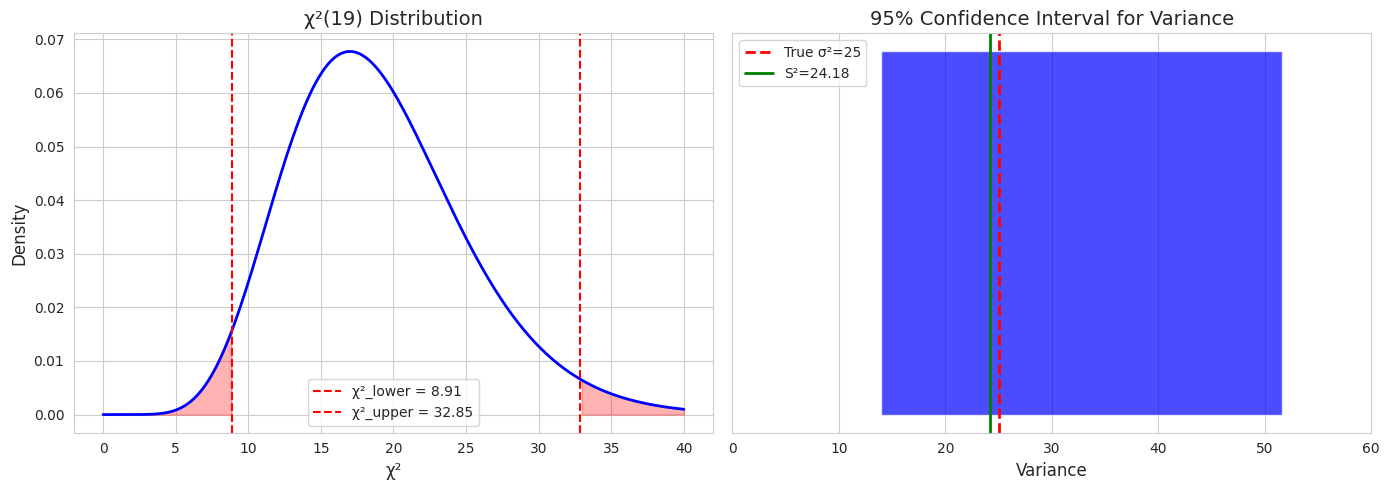

In [5]:
# 分散の信頼区間
np.random.seed(789)
n = 20
true_mu = 100
true_sigma2 = 25  # True variance

sample = np.random.normal(true_mu, np.sqrt(true_sigma2), n)
sample_var = np.var(sample, ddof=1)

alpha = 0.05
df = n - 1

# Chi-squared critical values
chi2_lower = stats.chi2.ppf(alpha/2, df)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df)

# Confidence interval for variance
ci_lower = (n - 1) * sample_var / chi2_upper
ci_upper = (n - 1) * sample_var / chi2_lower

# Confidence interval for standard deviation
ci_std_lower = np.sqrt(ci_lower)
ci_std_upper = np.sqrt(ci_upper)

print(f"Sample variance: {sample_var:.2f}")
print(f"True variance: {true_sigma2}")
print(f"\n95% CI for σ²: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"95% CI for σ:  [{ci_std_lower:.2f}, {ci_std_upper:.2f}]")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chi-squared distribution
x = np.linspace(0, 40, 200)
axes[0].plot(x, stats.chi2.pdf(x, df), 'b-', linewidth=2)
axes[0].fill_between(x[x < chi2_lower], stats.chi2.pdf(x[x < chi2_lower], df), alpha=0.3, color='red')
axes[0].fill_between(x[x > chi2_upper], stats.chi2.pdf(x[x > chi2_upper], df), alpha=0.3, color='red')
axes[0].axvline(chi2_lower, color='red', linestyle='--', label=f'χ²_lower = {chi2_lower:.2f}')
axes[0].axvline(chi2_upper, color='red', linestyle='--', label=f'χ²_upper = {chi2_upper:.2f}')
axes[0].set_xlabel('χ²', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'χ²({df}) Distribution', fontsize=14)
axes[0].legend()

# Confidence interval visualization
axes[1].barh(0, ci_upper - ci_lower, left=ci_lower, height=0.3, alpha=0.7, color='blue')
axes[1].axvline(true_sigma2, color='red', linestyle='--', linewidth=2, label=f'True σ²={true_sigma2}')
axes[1].axvline(sample_var, color='green', linestyle='-', linewidth=2, label=f'S²={sample_var:.2f}')
axes[1].set_xlim(0, 60)
axes[1].set_yticks([])
axes[1].set_xlabel('Variance', fontsize=12)
axes[1].set_title('95% Confidence Interval for Variance', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# 分散の信頼区間のカバレッジ検証
n_simulations = 10000
n = 15
true_sigma2 = 16
alpha = 0.05

df = n - 1
chi2_lower = stats.chi2.ppf(alpha/2, df)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df)

coverage_count = 0
widths = []

for _ in range(n_simulations):
    sample = np.random.normal(0, np.sqrt(true_sigma2), n)
    sample_var = np.var(sample, ddof=1)
    
    ci_lower = (n - 1) * sample_var / chi2_upper
    ci_upper = (n - 1) * sample_var / chi2_lower
    
    widths.append(ci_upper - ci_lower)
    
    if ci_lower <= true_sigma2 <= ci_upper:
        coverage_count += 1

coverage = coverage_count / n_simulations * 100
print(f"Coverage: {coverage:.2f}%")
print(f"Average width: {np.mean(widths):.2f}")

Coverage: 95.08%
Average width: 31.13


## 9.5 母比率の信頼区間

### 正規近似（大標本）
$$\hat{p} \pm z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

### ウィルソンの区間（より正確）
$$\frac{\hat{p} + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

Sample proportion: p̂ = 31/100 = 0.310
True proportion: p = 0.3

95% Confidence Intervals:
  Wald:           [0.219, 0.401]
  Wilson:         [0.228, 0.406]
  Clopper-Pearson: [0.221, 0.410]


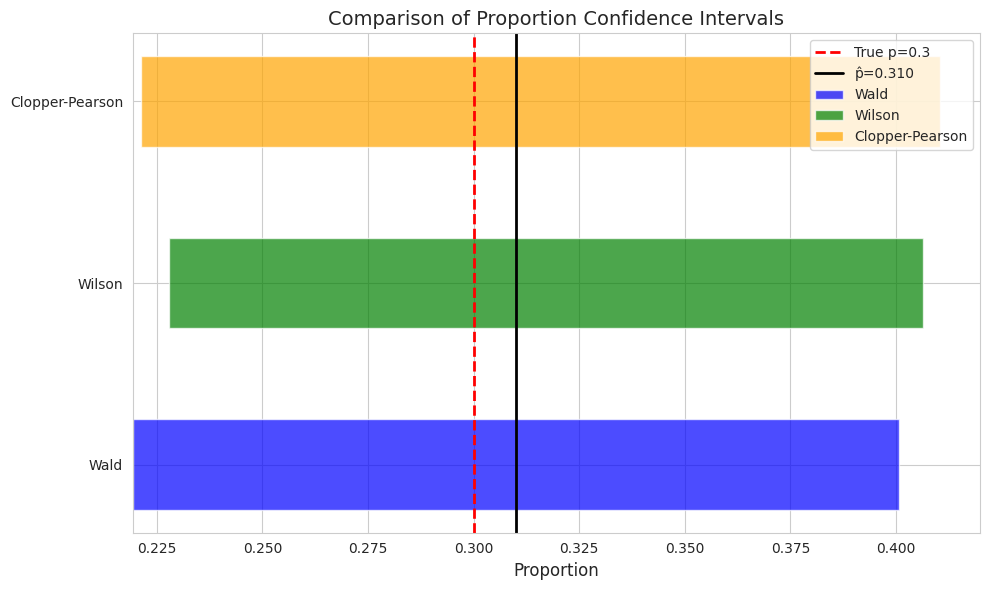

In [7]:
# 母比率の信頼区間
np.random.seed(111)
n = 100
true_p = 0.3

# Generate sample
x = np.random.binomial(n, true_p)  # Number of successes
p_hat = x / n

alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

# Wald interval (normal approximation)
se_wald = np.sqrt(p_hat * (1 - p_hat) / n)
wald_lower = p_hat - z * se_wald
wald_upper = p_hat + z * se_wald

# Wilson interval
denominator = 1 + z**2 / n
center = (p_hat + z**2 / (2*n)) / denominator
margin = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4*n**2)) / denominator
wilson_lower = center - margin
wilson_upper = center + margin

# Clopper-Pearson (exact) interval
cp_lower = stats.beta.ppf(alpha/2, x, n - x + 1) if x > 0 else 0
cp_upper = stats.beta.ppf(1 - alpha/2, x + 1, n - x) if x < n else 1

print(f"Sample proportion: p̂ = {x}/{n} = {p_hat:.3f}")
print(f"True proportion: p = {true_p}")
print(f"\n95% Confidence Intervals:")
print(f"  Wald:           [{wald_lower:.3f}, {wald_upper:.3f}]")
print(f"  Wilson:         [{wilson_lower:.3f}, {wilson_upper:.3f}]")
print(f"  Clopper-Pearson: [{cp_lower:.3f}, {cp_upper:.3f}]")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Wald', 'Wilson', 'Clopper-Pearson']
lowers = [wald_lower, wilson_lower, cp_lower]
uppers = [wald_upper, wilson_upper, cp_upper]
colors = ['blue', 'green', 'orange']

for i, (method, lower, upper, color) in enumerate(zip(methods, lowers, uppers, colors)):
    ax.barh(i, upper - lower, left=lower, height=0.5, alpha=0.7, color=color, label=method)

ax.axvline(true_p, color='red', linestyle='--', linewidth=2, label=f'True p={true_p}')
ax.axvline(p_hat, color='black', linestyle='-', linewidth=2, label=f'p̂={p_hat:.3f}')
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods)
ax.set_xlabel('Proportion', fontsize=12)
ax.set_title('Comparison of Proportion Confidence Intervals', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

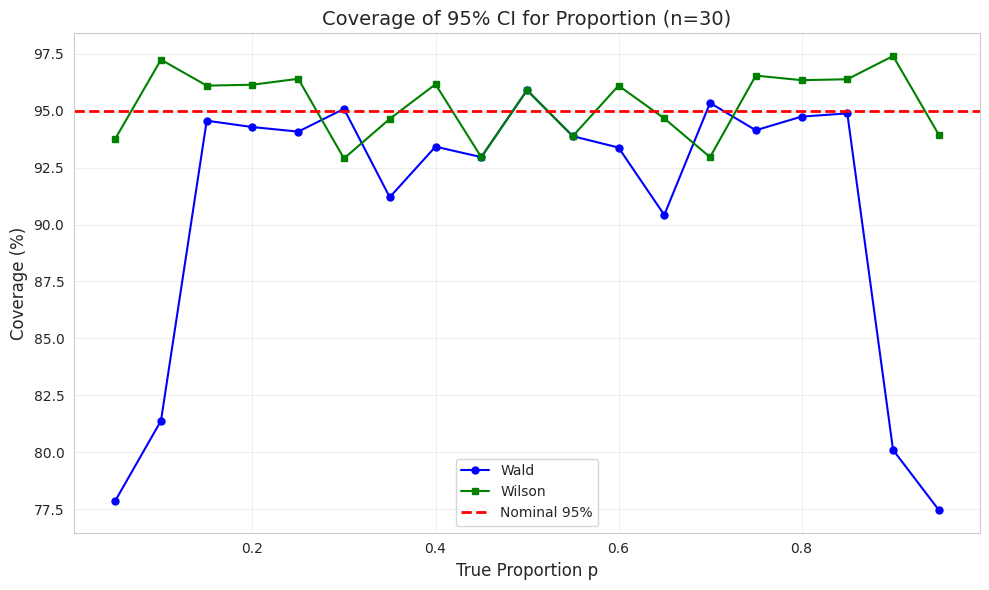

In [8]:
# 母比率の信頼区間：カバレッジの比較
n_simulations = 5000
n = 30
alpha = 0.05
z = stats.norm.ppf(1 - alpha/2)

p_values = np.linspace(0.05, 0.95, 19)
coverage_wald = []
coverage_wilson = []

for true_p in p_values:
    wald_covers = 0
    wilson_covers = 0
    
    for _ in range(n_simulations):
        x = np.random.binomial(n, true_p)
        p_hat = x / n
        
        # Wald
        se = np.sqrt(p_hat * (1 - p_hat) / n)
        if p_hat - z * se <= true_p <= p_hat + z * se:
            wald_covers += 1
        
        # Wilson
        denom = 1 + z**2 / n
        center = (p_hat + z**2 / (2*n)) / denom
        margin = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4*n**2)) / denom
        if center - margin <= true_p <= center + margin:
            wilson_covers += 1
    
    coverage_wald.append(wald_covers / n_simulations * 100)
    coverage_wilson.append(wilson_covers / n_simulations * 100)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(p_values, coverage_wald, 'b-o', markersize=5, label='Wald')
ax.plot(p_values, coverage_wilson, 'g-s', markersize=5, label='Wilson')
ax.axhline(95, color='red', linestyle='--', linewidth=2, label='Nominal 95%')

ax.set_xlabel('True Proportion p', fontsize=12)
ax.set_ylabel('Coverage (%)', fontsize=12)
ax.set_title(f'Coverage of 95% CI for Proportion (n={n})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9.6 ピボット量の方法

### 定義
ピボット量とは、データとパラメータの関数で、その分布がパラメータに依存しないもの。

### 信頼区間の構成手順
1. ピボット量 $Q(X, \theta)$ を見つける
2. $P(a \leq Q \leq b) = 1 - \alpha$ となる $a, b$ を求める
3. 不等式を $\theta$ について解く

Sample maximum: 4.178
True θ: 5

95% CI for θ: [4.178, 6.042]


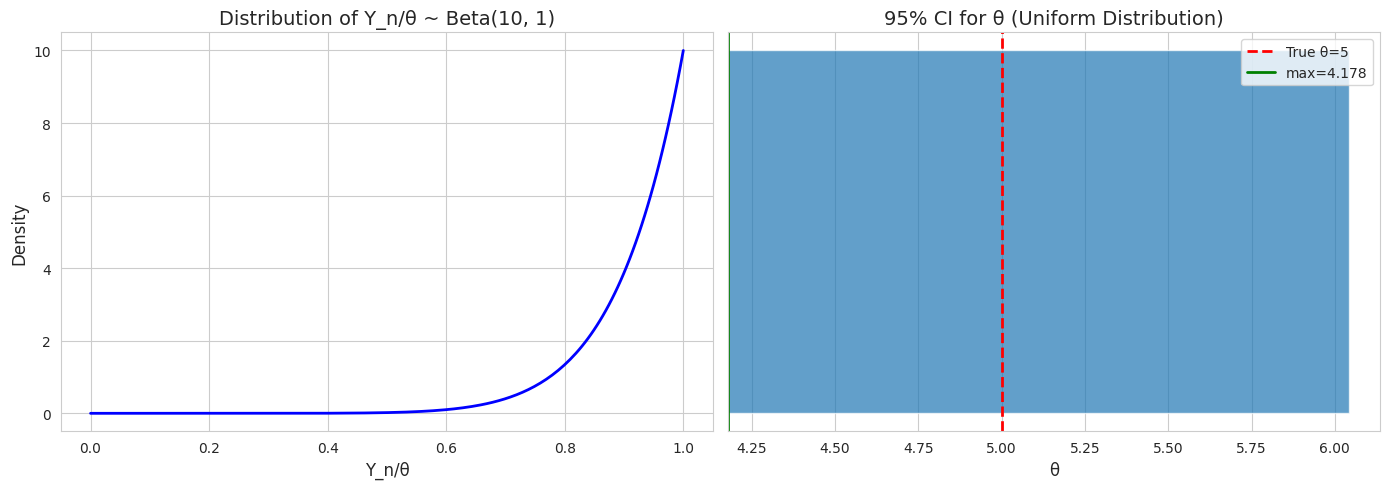

In [9]:
# ピボット量の例：一様分布 U(0, θ)
np.random.seed(222)
n = 10
true_theta = 5

sample = np.random.uniform(0, true_theta, n)
max_value = np.max(sample)

# Pivot quantity: Y_n/θ ~ Beta(n, 1)
# P((Y_n/θ)^n > alpha/2) = 1 - alpha/2
# Y_n/θ > (alpha/2)^(1/n)

alpha = 0.05

# Lower bound: θ > Y_n
# Upper bound from: P(Y_n/θ > c) = c^n
# We want P(Y_n/θ < upper_c) = 1 - alpha/2

lower_bound = max_value
upper_bound = max_value / (alpha/2)**(1/n)

print(f"Sample maximum: {max_value:.3f}")
print(f"True θ: {true_theta}")
print(f"\n95% CI for θ: [{lower_bound:.3f}, {upper_bound:.3f}]")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Y_n/θ
y = np.linspace(0, 1, 200)
pdf = n * y**(n-1)  # Beta(n, 1) PDF
axes[0].plot(y, pdf, 'b-', linewidth=2)
axes[0].set_xlabel('Y_n/θ', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'Distribution of Y_n/θ ~ Beta({n}, 1)', fontsize=14)

# Confidence interval
axes[1].barh(0, upper_bound - lower_bound, left=lower_bound, height=0.3, alpha=0.7)
axes[1].axvline(true_theta, color='red', linestyle='--', linewidth=2, label=f'True θ={true_theta}')
axes[1].axvline(max_value, color='green', linestyle='-', linewidth=2, label=f'max={max_value:.3f}')
axes[1].set_yticks([])
axes[1].set_xlabel('θ', fontsize=12)
axes[1].set_title('95% CI for θ (Uniform Distribution)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9.7 二標本問題の信頼区間

### 平均の差の信頼区間（分散既知）
$$(\bar{X} - \bar{Y}) \pm z_{\alpha/2} \sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}$$

### 平均の差の信頼区間（分散未知・等分散）
$$(\bar{X} - \bar{Y}) \pm t_{\alpha/2}(n_1+n_2-2) \cdot S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}$$

ここで $S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1+n_2-2}$

Sample 1: n=25, mean=49.50, var=54.25
Sample 2: n=30, mean=44.74, var=79.22
Pooled std: 8.24

True difference: μ1 - μ2 = 5
Sample difference: X̄1 - X̄2 = 4.76
95% CI for μ1 - μ2: [0.28, 9.23]


/tmp/ipykernel_14062/3089672362.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([sample1, sample2], labels=['Sample 1', 'Sample 2'])


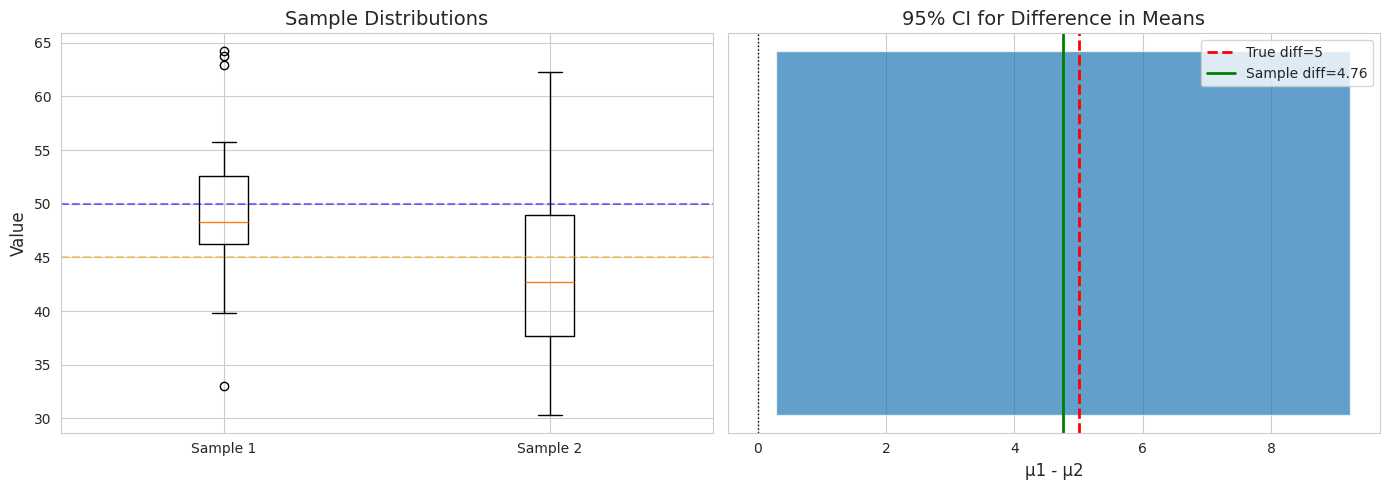

In [10]:
# 二標本の平均の差の信頼区間
np.random.seed(333)

# Sample data
n1, n2 = 25, 30
mu1, mu2 = 50, 45
sigma = 8  # Common standard deviation

sample1 = np.random.normal(mu1, sigma, n1)
sample2 = np.random.normal(mu2, sigma, n2)

# Statistics
mean1, mean2 = np.mean(sample1), np.mean(sample2)
var1, var2 = np.var(sample1, ddof=1), np.var(sample2, ddof=1)

# Pooled variance
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# Confidence interval
alpha = 0.05
df = n1 + n2 - 2
t_crit = stats.t.ppf(1 - alpha/2, df)

diff = mean1 - mean2
se = sp * np.sqrt(1/n1 + 1/n2)
ci_lower = diff - t_crit * se
ci_upper = diff + t_crit * se

print(f"Sample 1: n={n1}, mean={mean1:.2f}, var={var1:.2f}")
print(f"Sample 2: n={n2}, mean={mean2:.2f}, var={var2:.2f}")
print(f"Pooled std: {sp:.2f}")
print(f"\nTrue difference: μ1 - μ2 = {mu1 - mu2}")
print(f"Sample difference: X̄1 - X̄2 = {diff:.2f}")
print(f"95% CI for μ1 - μ2: [{ci_lower:.2f}, {ci_upper:.2f}]")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots
axes[0].boxplot([sample1, sample2], labels=['Sample 1', 'Sample 2'])
axes[0].axhline(mu1, color='blue', linestyle='--', alpha=0.5)
axes[0].axhline(mu2, color='orange', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Sample Distributions', fontsize=14)

# Confidence interval
axes[1].barh(0, ci_upper - ci_lower, left=ci_lower, height=0.3, alpha=0.7)
axes[1].axvline(mu1 - mu2, color='red', linestyle='--', linewidth=2, 
                label=f'True diff={mu1-mu2}')
axes[1].axvline(diff, color='green', linestyle='-', linewidth=2, 
                label=f'Sample diff={diff:.2f}')
axes[1].axvline(0, color='black', linestyle=':', linewidth=1)
axes[1].set_yticks([])
axes[1].set_xlabel('μ1 - μ2', fontsize=12)
axes[1].set_title('95% CI for Difference in Means', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9.8 大標本信頼区間

### 中心極限定理による近似
$$\bar{X} \pm z_{\alpha/2} \frac{S}{\sqrt{n}}$$

大きな $n$ では $t$ 分布と正規分布がほぼ一致。

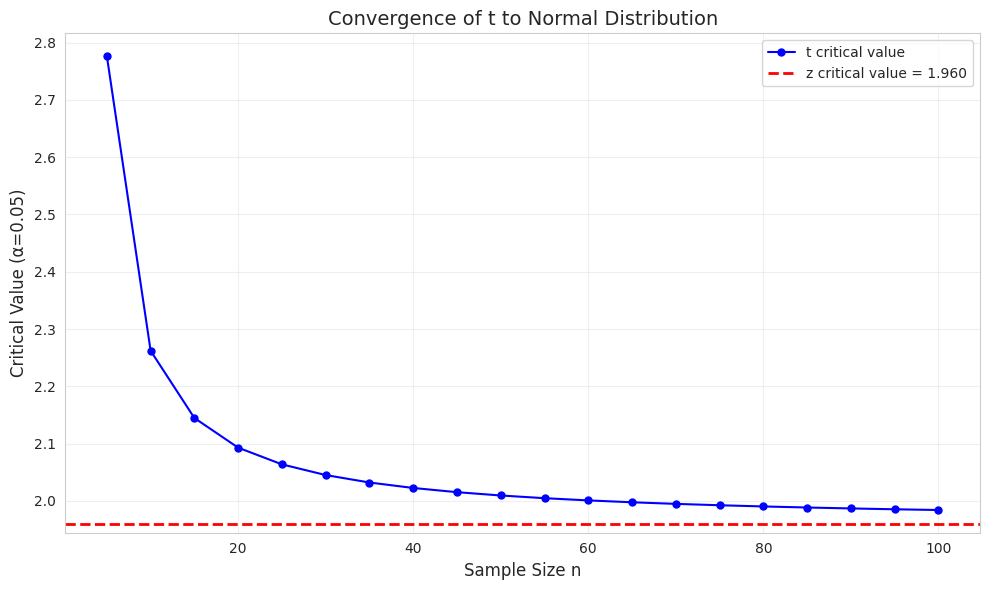

At n=30: t = 2.045, z = 1.960
At n=100: t = 1.984, z = 1.960


In [11]:
# 大標本近似の精度
alpha = 0.05
sample_sizes = np.arange(5, 101, 5)

z_crit = stats.norm.ppf(1 - alpha/2)
t_crits = [stats.t.ppf(1 - alpha/2, n-1) for n in sample_sizes]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sample_sizes, t_crits, 'b-o', markersize=5, label='t critical value')
ax.axhline(z_crit, color='red', linestyle='--', linewidth=2, label=f'z critical value = {z_crit:.3f}')

ax.set_xlabel('Sample Size n', fontsize=12)
ax.set_ylabel('Critical Value (α=0.05)', fontsize=12)
ax.set_title('Convergence of t to Normal Distribution', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"At n=30: t = {stats.t.ppf(1-alpha/2, 29):.3f}, z = {z_crit:.3f}")
print(f"At n=100: t = {stats.t.ppf(1-alpha/2, 99):.3f}, z = {z_crit:.3f}")

## 9.9 練習問題

### 問題1
正規母集団から16個の標本を取り、$\bar{x} = 50$, $s = 8$ を得た。母平均 $\mu$ の95%信頼区間を求めよ。

### 問題2
100人を調査したところ、35人が「はい」と回答した。母比率 $p$ の95%信頼区間を求めよ。

### 問題3
正規母集団から25個の標本を取り、$s^2 = 36$ を得た。母分散 $\sigma^2$ の90%信頼区間を求めよ。

In [12]:
# 問題1の解答
print("問題1: 母平均の信頼区間")
print("="*50)

n = 16
x_bar = 50
s = 8
alpha = 0.05

t_crit = stats.t.ppf(1 - alpha/2, n - 1)
margin = t_crit * s / np.sqrt(n)

ci_lower = x_bar - margin
ci_upper = x_bar + margin

print(f"t_0.025(15) = {t_crit:.3f}")
print(f"標準誤差 = {s/np.sqrt(n):.3f}")
print(f"\n95% CI for μ: [{ci_lower:.2f}, {ci_upper:.2f}]")

問題1: 母平均の信頼区間
t_0.025(15) = 2.131
標準誤差 = 2.000

95% CI for μ: [45.74, 54.26]


In [13]:
# 問題2の解答
print("問題2: 母比率の信頼区間")
print("="*50)

n = 100
x = 35
p_hat = x / n
alpha = 0.05

z = stats.norm.ppf(1 - alpha/2)

# Wald interval
se = np.sqrt(p_hat * (1 - p_hat) / n)
wald_lower = p_hat - z * se
wald_upper = p_hat + z * se

# Wilson interval
denom = 1 + z**2 / n
center = (p_hat + z**2 / (2*n)) / denom
margin = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4*n**2)) / denom

print(f"p̂ = {p_hat}")
print(f"z_0.025 = {z:.3f}")
print(f"\nWald 95% CI: [{wald_lower:.3f}, {wald_upper:.3f}]")
print(f"Wilson 95% CI: [{center - margin:.3f}, {center + margin:.3f}]")

問題2: 母比率の信頼区間
p̂ = 0.35
z_0.025 = 1.960

Wald 95% CI: [0.257, 0.443]
Wilson 95% CI: [0.264, 0.447]


In [14]:
# 問題3の解答
print("問題3: 母分散の信頼区間")
print("="*50)

n = 25
s2 = 36
alpha = 0.10
df = n - 1

chi2_lower = stats.chi2.ppf(alpha/2, df)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df)

ci_lower = (n - 1) * s2 / chi2_upper
ci_upper = (n - 1) * s2 / chi2_lower

print(f"χ²_0.05(24) = {chi2_lower:.3f}")
print(f"χ²_0.95(24) = {chi2_upper:.3f}")
print(f"\n90% CI for σ²: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"90% CI for σ:  [{np.sqrt(ci_lower):.2f}, {np.sqrt(ci_upper):.2f}]")

問題3: 母分散の信頼区間
χ²_0.05(24) = 13.848
χ²_0.95(24) = 36.415

90% CI for σ²: [23.73, 62.39]
90% CI for σ:  [4.87, 7.90]


## ⚠️ よくある間違いと解決策

### ❌ 信頼区間の誤解釈
**正しい理解:** 「母数が95%の確率で区間内」は誤り
**解決策:** 「同じ方法で100回推定したら95回は母数を含む区間が得られる」

### ❌ サンプルサイズと区間幅
**正しい理解:** nが大きいほど信頼区間は狭くなる
**解決策:** 区間幅∝1/√n

---

## 📝 理解度チェッククイズ

### 問題 1
95%信頼区間の正しい解釈を述べよ

### 問題 2
信頼区間を狭くする方法は？

---

## 📚 まとめ

お疲れ様でした！この章の内容は統計的推論の核心部分です。

---